# Treatment Escalation Following Metformin Initiation in Type 2 Diabetes
## A Descriptive Observational Study Using OMOP CDM Data

**Research Question:** Among adults with T2DM initiating metformin monotherapy, what demographic and clinical characteristics are associated with the *timing* of second-line antidiabetic therapy initiation?

**Study Design:** Descriptive observational study of new metformin users who subsequently initiated second-line antidiabetic therapy. Time to escalation is measured from the metformin index date to the first non-metformin antidiabetic prescription.

**Analytic Layers:**
1. **Descriptive Analysis** — Cohort characteristics, escalation rates, top agents
2. **Survival Analysis** — Kaplan-Meier curves and Cox proportional hazards regression
3. **Stratified Analyses** — By gender, race, ethnicity, age group, CHD, CKD, depression, hypertension
4. **Treatment Pathway Analysis** — Common sequences of therapy following metformin

**Team:** Giselle Feng (fg2618) and Nikhil Anand (na3213)

## 0. Setup and Imports

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 1. Data Loading and Cleaning

The raw data is at the **drug-exposure level**: each row represents one second-line drug exposure for a patient. A single patient may have multiple rows if they received multiple second-line agents over time.

The cleaning function below:
- Parses dates and standardizes categorical variables
- Standardizes drug names to lowercase for consistency
- Computes derived time variables (time to first escalation, follow-up duration)
- Collapses the data to **one row per patient** using the *first* second-line initiation event
- Creates age group bins for stratified analysis
- Computes censor date as min(cohort_start_date + 270 days, observation_period_end_date)

In [148]:
def clean_and_prepare(filepath):
    """
    Load raw drug-exposure-level data and return two DataFrames:
      1. df_raw  — all exposures within the study window (for pathway analysis)
      2. df      — one row per patient, first escalation event (for survival analysis)
    """

    raw = pd.read_csv(filepath)
    print(f"Raw data: {len(raw)} rows, {raw['person_id'].nunique()} unique patients")

    # --- Parse dates ---
    date_cols = [
        "cohort_start_date",
        "cohort_end_date",
        "observation_period_start_date",
        "observation_period_end_date",
        "second_line_start_date",
        "second_line_end_date",
        "censor_date",
    ]
    for col in date_cols:
        raw[col] = pd.to_datetime(raw[col], errors="coerce")

    # --- Drop exposures outside the study window ---
    before = len(raw)
    raw = raw[raw["second_line_start_date"] <= raw["cohort_end_date"]].copy()
    dropped = before - len(raw)
    print(f"Dropped {dropped} exposures after study end date (cohort_end_date)")
    print(f"Remaining: {len(raw)} exposures, {raw['person_id'].nunique()} patients")

    # --- Standardize ---
    raw["second_line_drug_name"] = raw["second_line_drug_name"].str.strip().str.lower()
    raw["gender"] = raw["gender"].str.strip().str.upper()
    raw["race"] = raw["race"].str.strip()
    raw["ethnicity"] = raw["ethnicity"].str.strip()

    # --- Days from metformin start to each exposure ---
    raw["days_to_drug"] = (
        raw["second_line_start_date"] - raw["cohort_start_date"]
    ).dt.days

    # --- Flag anomalies ---
    neg = raw[raw["days_to_drug"] < 0]
    if len(neg) > 0:
        print(f"WARNING: {len(neg)} exposures with negative time. Removing.")
        raw = raw[raw["days_to_drug"] >= 0].copy()

    same_day = raw[raw["days_to_drug"] == 0]
    if len(same_day) > 0:
        print(
            f"NOTE: {len(same_day)} exposures on day 0 (same day as metformin start)."
        )

    # --- Study period length ---
    raw["study_period_days"] = (
        raw["cohort_end_date"] - raw["cohort_start_date"]
    ).dt.days
    print(
        f"Study period: {raw['study_period_days'].iloc[0]} days "
        f"({raw['cohort_start_date'].iloc[0].date()} to {raw['cohort_end_date'].iloc[0].date()})"
    )

    # --- Save cleaned full dataset for pathway analysis ---
    df_raw = raw.copy()

    # --- Collapse to one row per patient: first second-line event ---
    raw = raw.sort_values(["person_id", "second_line_start_date"])
    df = raw.groupby("person_id").first().reset_index()

    # --- Time to first escalation ---
    df["time_to_escalation"] = (
        df["second_line_start_date"] - df["cohort_start_date"]
    ).dt.days

    print(
        "Number of records with zero time to escalation days",
        len(df[df["time_to_escalation"] == 0]),
    )
    print("These will be pruned!")
    df = df[df["time_to_escalation"] > 0]

    # --- Event indicator (all = 1, everyone escalated) ---
    df["event"] = 1

    # --- Age groups ---
    df["age_group"] = pd.cut(
        df["age_at_index"],
        bins=[17, 44, 64, 74, 120],
        labels=["18-44", "45-64", "65-74", "75+"],
    )

    # --- Rename flags ---
    df = df.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )
    df_raw = df_raw.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )

    print("Removing any records where the time to escalation equals the study period")
    df = df[df["study_period_days"] > df["time_to_escalation"]]

    print(f"\nPatient-level data: {len(df)} patients")
    print(f"  Median time to escalation: {df['time_to_escalation'].median():.0f} days")
    print(
        f"  Range: {df['time_to_escalation'].min()} – {df['time_to_escalation'].max()} days"
    )

    return df_raw, df


df_raw, df = clean_and_prepare("../Data/cohort_raw.csv")
df.head()

Raw data: 25182 rows, 9951 unique patients
Dropped 8419 exposures after study end date (cohort_end_date)
Remaining: 16763 exposures, 9116 patients
NOTE: 1867 exposures on day 0 (same day as metformin start).
Study period: 334 days (2009-01-15 to 2009-12-15)
Number of records with zero time to escalation days 1860
These will be pruned!
Removing any records where the time to escalation equals the study period

Patient-level data: 5161 patients
  Median time to escalation: 68 days
  Range: 1 – 326 days


,person_id,gender,race,ethnicity,age_at_index,cohort_start_date,cohort_end_date,observation_period_start_date,observation_period_end_date,second_line_drug_name,...,hypertension,depression,chd,ckd,censor_date,days_to_drug,study_period_days,time_to_escalation,event,age_group
3,82,MALE,White,Not Hispanic or Latino,81,2009-05-01,2010-03-31,2008-01-05,2010-06-05,rosiglitazone,...,1,0,1,0,NaT,38,334,38,1,75+
4,83,FEMALE,White,Not Hispanic or Latino,46,2009-05-30,2010-02-16,2008-02-08,2010-12-31,pioglitazone,...,0,1,1,0,2010-02-16,132,262,132,1,45-64
7,142,FEMALE,White,Not Hispanic or Latino,72,2009-01-27,2009-12-27,2008-01-24,2010-10-29,glyburide,...,0,0,0,0,2010-06-06,250,334,250,1,65-74
8,147,FEMALE,White,Not Hispanic or Latino,83,2009-06-21,2010-05-21,2008-01-18,2010-08-12,glyburide,...,0,0,1,1,NaT,135,334,135,1,75+
10,178,MALE,White,Not Hispanic or Latino,81,2009-03-18,2010-02-15,2008-01-17,2010-08-30,glimepiride,...,0,1,1,1,2010-04-14,34,334,34,1,75+


---
## Layer 1: Descriptive Analysis

### 1.1 Table 1 — Baseline Characteristics

Standard summary of cohort demographics and comorbidities, reported as counts and percentages for categorical variables, and median (IQR) for continuous variables.

In [149]:
def make_table1(df):
    """Generate a Table 1 of baseline characteristics."""

    rows = []
    N = len(df)

    # --- Continuous: Age ---
    med = df["age_at_index"].median()
    q1 = df["age_at_index"].quantile(0.25)
    q3 = df["age_at_index"].quantile(0.75)
    rows.append(("Median Age at Index (IQR)", f"{med:.0f} ({q1:.0f}–{q3:.0f})", ""))

    # --- Continuous: Time to escalation ---
    med_t = df["time_to_escalation"].median()
    q1_t = df["time_to_escalation"].quantile(0.25)
    q3_t = df["time_to_escalation"].quantile(0.75)
    rows.append(
        (
            "Time to escalation (days), median (IQR)",
            f"{med_t:.0f} ({q1_t:.0f}–{q3_t:.0f})",
            "",
        )
    )

    rows.append(("", "", ""))  # spacer

    # --- Categorical variables ---
    cat_vars = {
        "Gender": "gender",
        "Race": "race",
        "Ethnicity": "ethnicity",
        "Age group": "age_group",
    }
    for label, col in cat_vars.items():
        rows.append((f"**{label}**", "n", "%"))
        for val in sorted(df[col].dropna().unique()):
            n = (df[col] == val).sum()
            pct = n / N * 100
            rows.append((f"  {val}", str(n), f"{pct:.1f}%"))

    # --- Binary comorbidity flags ---
    rows.append(("", "", ""))
    rows.append(("**Comorbidities**", "n", "%"))
    for label, col in [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ]:
        n = df[col].sum()
        pct = n / N * 100
        rows.append((f"  {label}", str(int(n)), f"{pct:.1f}%"))

    # --- Comorbidity count ---
    df_temp = df.copy()
    df_temp["comorbidity_count"] = df_temp[
        ["hypertension", "depression", "chd", "ckd"]
    ].sum(axis=1)
    med_c = df_temp["comorbidity_count"].median()
    mean_c = df_temp["comorbidity_count"].mean()
    rows.append(
        (f"Comorbidity count (of 4), median (mean)", f"{med_c:.0f} ({mean_c:.1f})", "")
    )

    table1 = pd.DataFrame(rows, columns=["Characteristic", "Value", ""])
    return table1


table1 = make_table1(df)
print("TABLE 1: Baseline Characteristics")
print("=" * 60)
print(table1.to_string(index=False))

TABLE 1: Baseline Characteristics
                         Characteristic       Value       
              Median Age at Index (IQR)  74 (67–82)       
Time to escalation (days), median (IQR) 68 (31–127)       
                                                          
                             **Gender**           n      %
                                 FEMALE        3213  62.3%
                                   MALE        1948  37.7%
                               **Race**           n      %
              Black or African American         648  12.6%
                                  White        4513  87.4%
                          **Ethnicity**           n      %
                 Not Hispanic or Latino        5161 100.0%
                          **Age group**           n      %
                                  18-44         218   4.2%
                                  45-64         803  15.6%
                                  65-74        1711  33.2%
                      

### 1.2 Top Second-Line Agents

Distribution of the first second-line antidiabetic agent initiated after metformin.

First second-line agent initiated after metformin:
---------------------------------------------
  glyburide             n=2009  (38.9%)
  glipizide             n=1585  (30.7%)
  glimepiride           n=502  (9.7%)
  rosiglitazone         n=443  (8.6%)
  pioglitazone          n=366  (7.1%)
  sitagliptin           n= 90  (1.7%)
  repaglinide           n= 88  (1.7%)
  nateglinide           n= 55  (1.1%)
  insulin glargine      n= 16  (0.3%)
  insulin detemir       n=  5  (0.1%)
  saxagliptin           n=  2  (0.0%)
                      N=5161


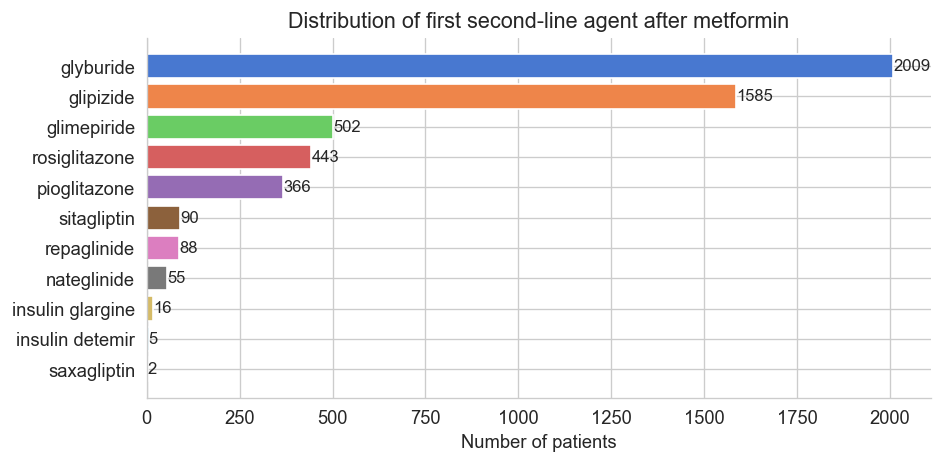

In [150]:
# Top second-line agents (first agent per patient)
drug_counts = df["second_line_drug_name"].value_counts()
drug_pcts = (drug_counts / len(df) * 100).round(1)

print("First second-line agent initiated after metformin:")
print("-" * 45)
for drug, n in drug_counts.items():
    print(f"  {drug:<20s}  n={n:>3d}  ({drug_pcts[drug]:.1f}%)")
print(f"{'':20s}  N={drug_counts.sum():>3d}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("muted", len(drug_counts))
bars = ax.barh(
    drug_counts.index[::-1],
    drug_counts.values[::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Number of patients")
ax.set_title("Distribution of first second-line agent after metformin")
for bar, val in zip(bars, drug_counts.values[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=10,
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 1.3 Distribution of Time to Escalation

Histogram and descriptive statistics for the primary outcome: days from metformin initiation to first second-line drug.

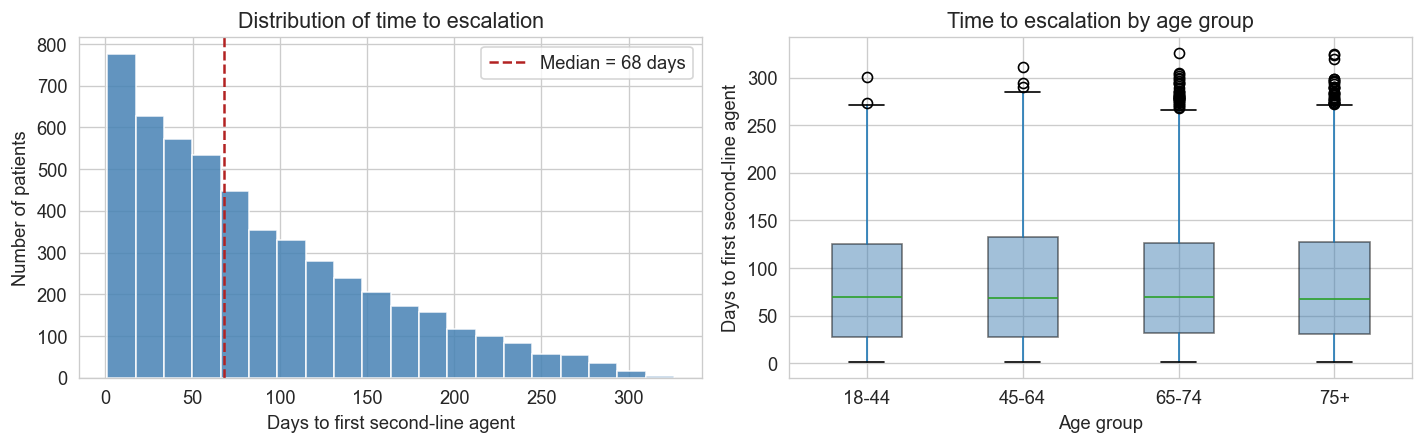


Descriptive statistics — Time to escalation (days):
count    5161.0
mean       86.3
std        69.2
min         1.0
25%        31.0
50%        68.0
75%       127.0
max       326.0
Name: time_to_escalation, dtype: float64


In [151]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(
    df["time_to_escalation"], bins=20, color="steelblue", edgecolor="white", alpha=0.85
)
axes[0].axvline(
    df["time_to_escalation"].median(),
    color="firebrick",
    linestyle="--",
    label=f"Median = {df['time_to_escalation'].median():.0f} days",
)
axes[0].set_xlabel("Days to first second-line agent")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Distribution of time to escalation")
axes[0].legend()

# Box plot by age group
df.boxplot(
    column="time_to_escalation",
    by="age_group",
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Days to first second-line agent")
axes[1].set_title("Time to escalation by age group")
plt.suptitle("")  # remove automatic pandas suptitle

plt.tight_layout()
plt.show()

# Summary stats
print("\nDescriptive statistics — Time to escalation (days):")
print(df["time_to_escalation"].describe().round(1))

### 1.4 Comorbidity Co-occurrence

Cross-tabulation of baseline comorbidities to understand burden and co-occurrence patterns.

Comorbidity count distribution:
comorbidity_count
0     503
1    1119
2    1720
3    1600
4     219
Name: count, dtype: int64

Comorbidity co-occurrence matrix (counts):
              hypertension  depression   chd   ckd
hypertension           479         315   442   317
depression             315        2661  2455  1729
chd                    442        2455  4293  2576
ckd                    317        1729  2576  2802


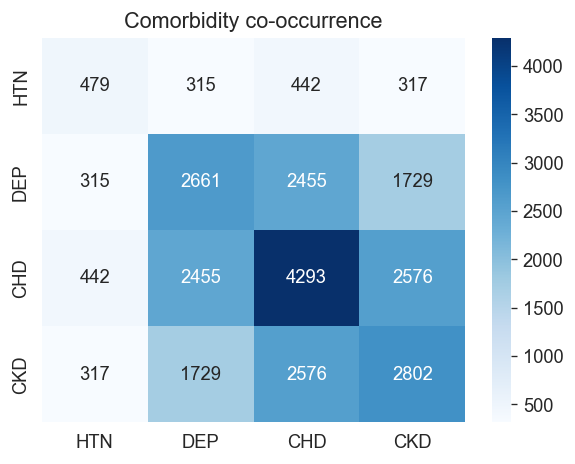

In [152]:
comorbidity_cols = ["hypertension", "depression", "chd", "ckd"]

# Comorbidity count distribution
df["comorbidity_count"] = df[comorbidity_cols].sum(axis=1)
print("Comorbidity count distribution:")
print(df["comorbidity_count"].value_counts().sort_index())
print()

# Co-occurrence matrix
co_matrix = pd.DataFrame(index=comorbidity_cols, columns=comorbidity_cols, dtype=float)
for c1 in comorbidity_cols:
    for c2 in comorbidity_cols:
        if c1 == c2:
            co_matrix.loc[c1, c2] = df[c1].sum()
        else:
            co_matrix.loc[c1, c2] = ((df[c1] == 1) & (df[c2] == 1)).sum()

print("Comorbidity co-occurrence matrix (counts):")
print(co_matrix.astype(int))

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    co_matrix.astype(int),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["HTN", "DEP", "CHD", "CKD"],
    yticklabels=["HTN", "DEP", "CHD", "CKD"],
)
ax.set_title("Comorbidity co-occurrence")
plt.tight_layout()
plt.show()

### 1.5 Time to Escalation by Comorbidity Status

Comparing median escalation times across comorbidity subgroups to identify preliminary patterns before formal modeling.

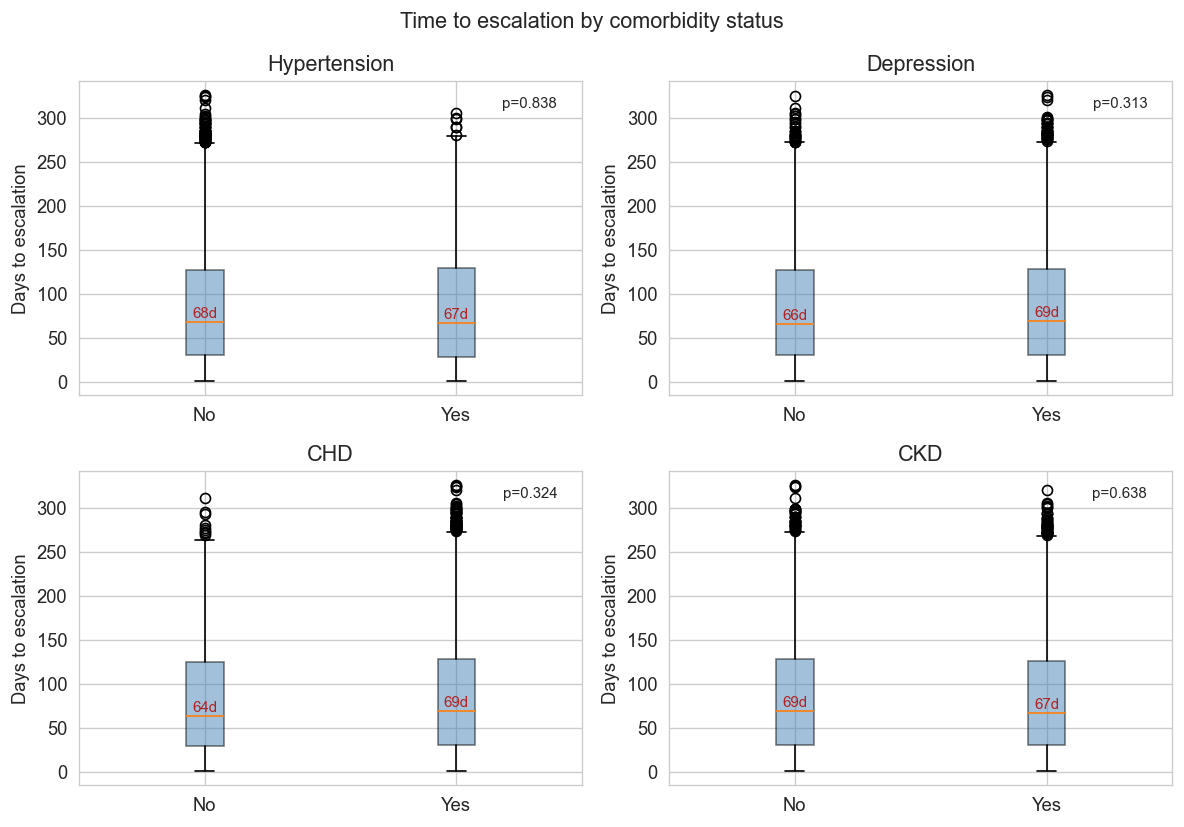

In [153]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, (label, col) in zip(
    axes.ravel(),
    [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ],
):
    groups = df.groupby(col)["time_to_escalation"]
    medians = groups.median()

    data_0 = df[df[col] == 0]["time_to_escalation"]
    data_1 = df[df[col] == 1]["time_to_escalation"]

    ax.boxplot(
        [data_0, data_1],
        labels=["No", "Yes"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(f"{label}")
    ax.set_ylabel("Days to escalation")

    # Add median labels
    for i, (grp, med) in enumerate(medians.items()):
        ax.text(
            i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick"
        )

    # Mann-Whitney U test
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
        ax.text(
            0.95,
            0.95,
            f"p={p:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )

plt.suptitle("Time to escalation by comorbidity status", fontsize=13)
plt.tight_layout()
plt.show()

---
## Layer 2: Survival Analysis

### 2.1 Overall Kaplan-Meier Curve

Since all patients in this dataset were escalated (event = 1 for all), the KM curve shows the cumulative proportion who have been escalated over time. There are no censored observations.

**Limitation:** This dataset includes only patients who *were* escalated. Patients who remained on metformin monotherapy throughout the observation period are excluded. The KM curve therefore represents the distribution of escalation timing conditional on escalation occurring, not the overall probability of escalation in the full cohort.

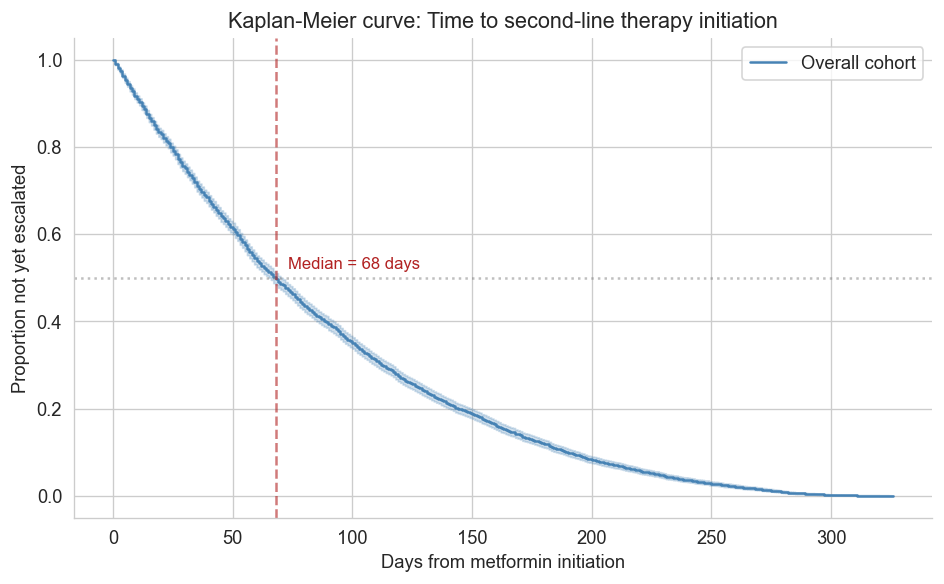

Median time to escalation: 68 days
Mean time to escalation: 86.3 days


In [154]:
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(8, 5))

kmf.fit(df["time_to_escalation"], event_observed=df["event"], label="Overall cohort")
kmf.plot_survival_function(ax=ax, ci_show=True, color="steelblue")

ax.set_xlabel("Days from metformin initiation")
ax.set_ylabel("Proportion not yet escalated")
ax.set_title("Kaplan-Meier curve: Time to second-line therapy initiation")
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)

median_surv = kmf.median_survival_time_
ax.axvline(x=median_surv, color="firebrick", linestyle="--", alpha=0.6)
ax.text(
    median_surv + 5,
    0.52,
    f"Median = {median_surv:.0f} days",
    color="firebrick",
    fontsize=10,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median time to escalation: {median_surv:.0f} days")
print(f"Mean time to escalation: {df['time_to_escalation'].mean():.1f} days")

### 2.2 Kaplan-Meier Curves — Stratified

KM curves stratified by each demographic and clinical characteristic, with log-rank tests for group differences.

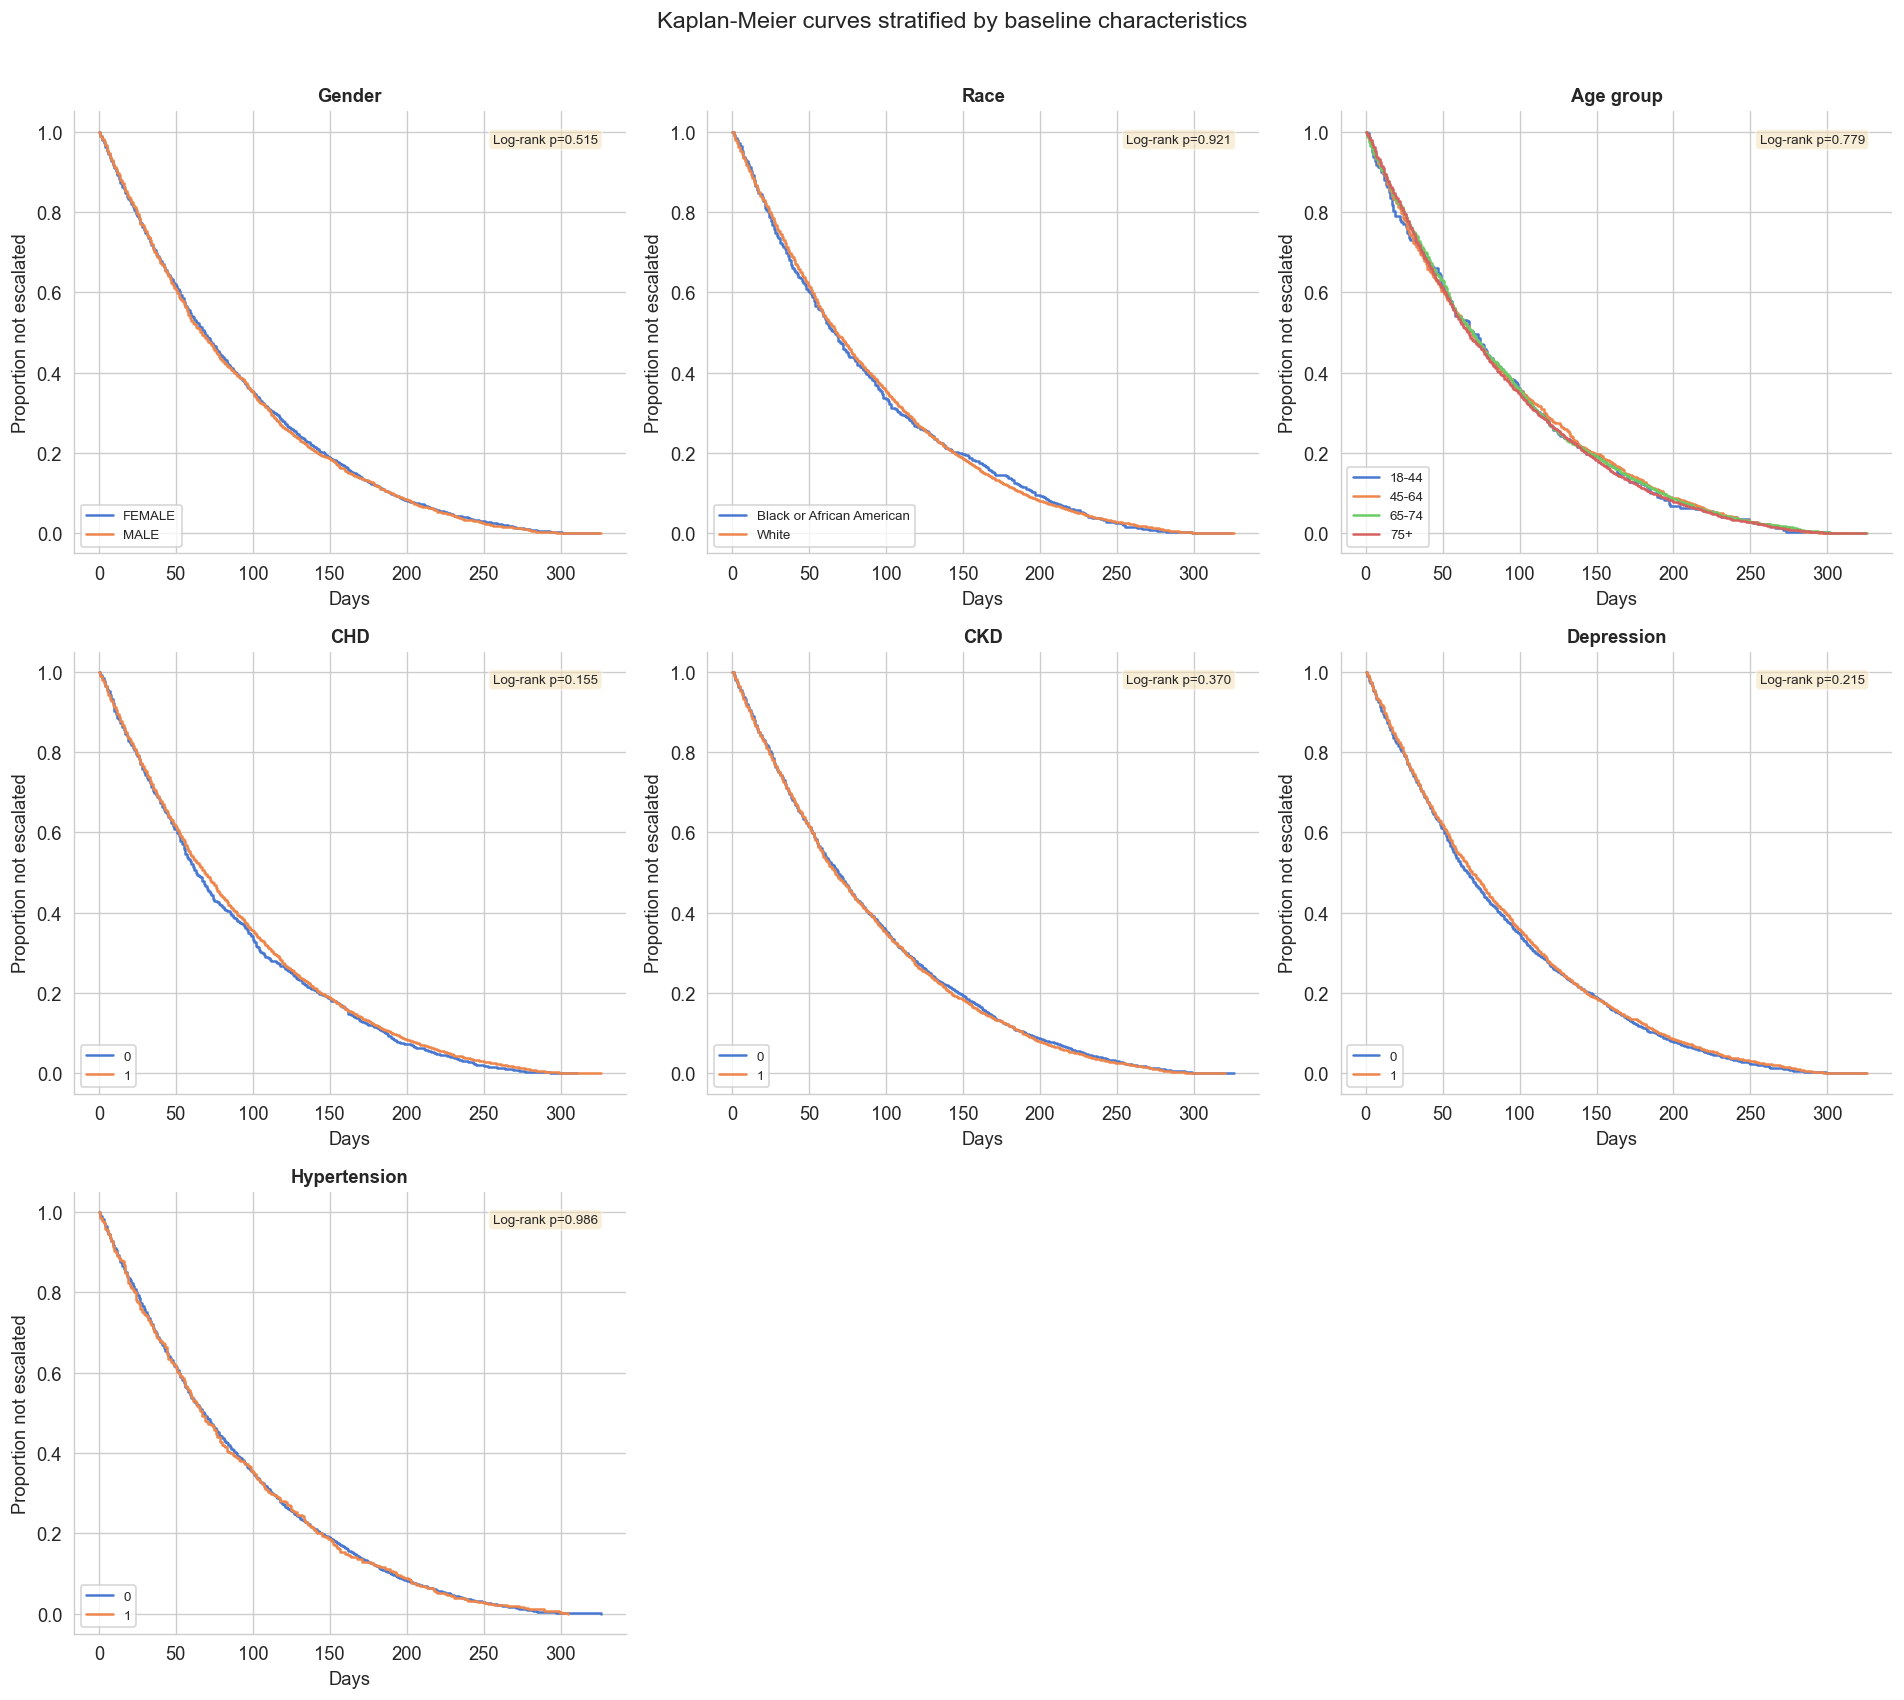

In [155]:
strat_vars = {
    'Gender': 'gender',
    'Race': 'race',
    'Age group': 'age_group',
    'CHD': 'chd',
    'CKD': 'ckd',
    'Depression': 'depression',
    'Hypertension': 'hypertension',
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()

kmf = KaplanMeierFitter()

for idx, (title, col) in enumerate(strat_vars.items()):
    ax = axes[idx]
    groups = df[col].dropna().unique()
    groups = sorted(groups, key=lambda x: str(x))
    
    palette = sns.color_palette("muted", len(groups))
    
    for i, grp in enumerate(groups):
        mask = df[col] == grp
        if mask.sum() < 2:
            continue
        kmf.fit(df.loc[mask, 'time_to_escalation'],
                event_observed=df.loc[mask, 'event'],
                label=str(grp))
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Proportion not escalated')
    ax.legend(fontsize=8, loc='lower left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Log-rank test (only if >=2 groups with >=2 observations each)
    valid_groups = [g for g in groups if (df[col] == g).sum() >= 2]
    if len(valid_groups) >= 2:
        try:
            result = multivariate_logrank_test(
                df.loc[df[col].isin(valid_groups), 'time_to_escalation'],
                df.loc[df[col].isin(valid_groups), col],
                df.loc[df[col].isin(valid_groups), 'event']
            )
            p = result.p_value
            ax.text(0.95, 0.95, f'Log-rank p={p:.3f}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
        except Exception:
            pass

# Hide unused axes
for idx in range(len(strat_vars), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Kaplan-Meier curves stratified by baseline characteristics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Cox Proportional Hazards Model

A multivariable Cox regression to identify characteristics independently associated with the hazard (rate) of second-line therapy initiation. 

**Interpretation:** A hazard ratio > 1 means faster escalation (shorter time to second-line therapy). A hazard ratio < 1 means slower escalation.

Covariates: age (continuous), gender, race, CHD, CKD, depression, hypertension.

In [156]:
# Prepare data for Cox regression
cox_df = df[
    [
        "time_to_escalation",
        "event",
        "age_at_index",
        "gender",
        "race",
        "chd",
        "ckd",
        "depression",
        "hypertension",
    ]
].copy()

# Encode gender: FEMALE = 0, MALE = 1
cox_df["male"] = (cox_df["gender"] == "MALE").astype(int)

# Encode race: dummies with White as reference
race_dummies = pd.get_dummies(cox_df["race"], prefix="race", drop_first=False)
# Use White as reference if present
if "race_White" in race_dummies.columns:
    race_dummies = race_dummies.drop(columns=["race_White"])
else:
    race_dummies = race_dummies.iloc[:, 1:]  # drop first alphabetically

cox_df = pd.concat([cox_df, race_dummies], axis=1)
cox_df = cox_df.drop(columns=["gender", "race"])

# Rename for readability
cox_df.columns = [c.replace("race_", "race: ") for c in cox_df.columns]

print("Cox model input shape:", cox_df.shape)
print("\nVariable summary:")
print(cox_df.describe().T[["mean", "std", "min", "max"]].round(2))

Cox model input shape: (5161, 9)

Variable summary:
                     mean    std   min    max
time_to_escalation  86.28  69.19   1.0  326.0
event                1.00   0.00   1.0    1.0
age_at_index        72.64  13.66  26.0  100.0
chd                  0.83   0.37   0.0    1.0
ckd                  0.54   0.50   0.0    1.0
depression           0.52   0.50   0.0    1.0
hypertension         0.09   0.29   0.0    1.0
male                 0.38   0.48   0.0    1.0


In [157]:
# Fit Cox PH model
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='time_to_escalation', event_col='event')

print("\n" + "=" * 70)
print("COX PROPORTIONAL HAZARDS MODEL — RESULTS")
print("=" * 70)
cph.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%'])


COX PROPORTIONAL HAZARDS MODEL — RESULTS


<lifelines.CoxPHFitter: fitted with 5161 total observations, 0 right-censored observations>
             duration col = 'time_to_escalation'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 5161
number of events observed = 5161
   partial log-likelihood = -38962.00
         time fit was run = 2026-04-19 20:32:40 UTC

---
                                 coef exp(coef)  se(coef) exp(coef) lower 95% exp(coef) upper 95%    p
covariate                                                                                             
age_at_index                     0.00      1.00      0.00                1.00                1.00 0.44
chd                             -0.06      0.94      0.04                0.87                1.02 0.15
ckd                              0.04      1.04      0.03                0.98                1.10 0.15
depression                      -0.03      0.97      0.03                0.91                1.03 0.27
hypertension                     0.00      1.00      0.05                0.91                1.10 0.92
male                             0.02      1.02      0.03                0.96                1.08 0.47
race: Black or African American  0.01      1.01      0.04                0.93                1.10 0.79
---
Concordance = 0.51
Partial AIC = 77938.00
log-likelihood ratio test = 5.98 on 7 df
-log2(p) of ll-ratio test = 0.88

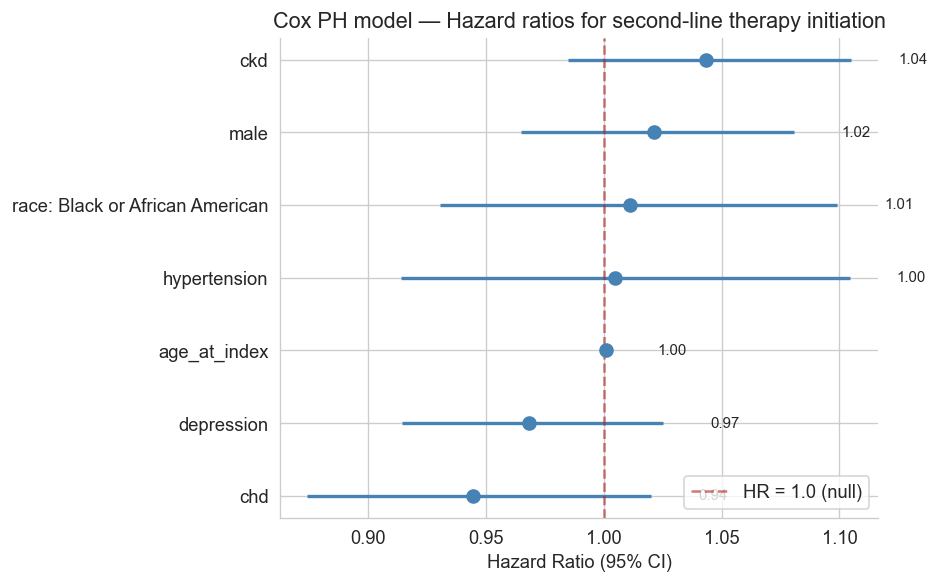

In [158]:
# Forest plot of hazard ratios
fig, ax = plt.subplots(figsize=(8, 5))

summary = cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']].copy()
summary = summary.sort_values('exp(coef)')

y_pos = range(len(summary))
ax.hlines(y_pos, summary['exp(coef) lower 95%'], summary['exp(coef) upper 95%'],
          color='steelblue', linewidth=2)
ax.scatter(summary['exp(coef)'], y_pos, color='steelblue', s=60, zorder=3)
ax.axvline(x=1.0, color='firebrick', linestyle='--', alpha=0.6, label='HR = 1.0 (null)')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Cox PH model — Hazard ratios for second-line therapy initiation')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower right')

# Add HR labels
for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(row['exp(coef) upper 95%'] + 0.02, i,
            f"{row['exp(coef)']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 2.4 Cox Model Diagnostics

Checking the proportional hazards assumption via Schoenfeld residual tests. A significant p-value (< 0.05) suggests the proportional hazards assumption may be violated for that covariate.

In [159]:
# Proportional hazards test
print("Proportional Hazards Assumption Test (Schoenfeld residuals)")
print("=" * 60)
try:
    ph_test = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"PH test result: {e}")
    print("\nNote: With a small sample (N=~50) and no censoring, these tests have")
    print("limited power. Interpret with caution.")

Proportional Hazards Assumption Test (Schoenfeld residuals)
Proportional hazard assumption looks okay.


---
## Layer 3: Stratified Cox Models

Running separate Cox models within demographic and clinical subgroups to examine whether the effect of covariates on escalation timing varies across strata. 

For binary stratification variables, we compare HRs across strata; for multi-level variables (age group, race), we describe covariate effects within each stratum.

In [160]:
def run_stratified_cox(df, strat_col, strat_label, covariate_cols):
    """
    Run Cox PH model within each stratum of strat_col.
    Returns a summary DataFrame of HRs across strata.
    """
    results = []
    strata = sorted(df[strat_col].dropna().unique(), key=lambda x: str(x))
    
    for stratum in strata:
        subset = df[df[strat_col] == stratum].copy()
        if len(subset) < 10:
            print(f"  Skipping {strat_label}={stratum}: n={len(subset)} (too few)")
            continue
        
        # Select covariates that have variance in this subset
        valid_covs = []
        for c in covariate_cols:
            if c in subset.columns and subset[c].nunique() > 1:
                valid_covs.append(c)
        
        if len(valid_covs) == 0:
            print(f"  Skipping {strat_label}={stratum}: no valid covariates with variance")
            continue
        
        model_df = subset[['time_to_escalation', 'event'] + valid_covs].dropna()
        
        if len(model_df) < 10:
            continue
        
        try:
            cph_s = CoxPHFitter(penalizer=0.1)  # light regularization for small strata
            cph_s.fit(model_df, duration_col='time_to_escalation', event_col='event')
            
            for cov in valid_covs:
                hr = cph_s.hazard_ratios_[cov]
                ci_low = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[0])
                ci_high = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[1])
                p = cph_s.summary.loc[cov, 'p']
                results.append({
                    'Stratum': f'{strat_label}={stratum}',
                    'N': len(model_df),
                    'Covariate': cov,
                    'HR': hr,
                    'CI_low': ci_low,
                    'CI_high': ci_high,
                    'p': p
                })
        except Exception as e:
            print(f"  {strat_label}={stratum}: model failed ({e})")
    
    return pd.DataFrame(results)


# Core covariates for stratified models
base_covs = ['age_at_index', 'male', 'chd', 'ckd', 'depression', 'hypertension']

# Prepare male variable in df if not already
df['male'] = (df['gender'] == 'MALE').astype(int)

print("=" * 70)
print("STRATIFIED COX MODELS")
print("=" * 70)

STRATIFIED COX MODELS


In [161]:
# Stratify by gender
print("\n--- Stratified by Gender ---")
gender_results = run_stratified_cox(df, 'gender', 'Gender',
    ['age_at_index', 'chd', 'ckd', 'depression', 'hypertension'])
if len(gender_results) > 0:
    print(gender_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Gender ---
      Stratum    N    Covariate    HR  CI_low  CI_high     p
Gender=FEMALE 3213 age_at_index 1.001   0.999    1.004 0.402
Gender=FEMALE 3213          chd 0.982   0.895    1.078 0.704
Gender=FEMALE 3213          ckd 1.067   0.996    1.143 0.065
Gender=FEMALE 3213   depression 0.943   0.880    1.009 0.090
Gender=FEMALE 3213 hypertension 0.974   0.869    1.093 0.659
  Gender=MALE 1948 age_at_index 1.000   0.997    1.003 0.931
  Gender=MALE 1948          chd 0.895   0.795    1.008 0.066
  Gender=MALE 1948          ckd 0.989   0.905    1.081 0.809
  Gender=MALE 1948   depression 1.025   0.938    1.120 0.588
  Gender=MALE 1948 hypertension 1.051   0.909    1.215 0.504


In [162]:
# Stratify by age group
print("\n--- Stratified by Age Group ---")
age_results = run_stratified_cox(
    df, "age_group", "Age", ["male", "chd", "ckd", "depression", "hypertension"]
)
if len(age_results) > 0:
    print(age_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Age Group ---
  Stratum    N    Covariate    HR  CI_low  CI_high     p
Age=18-44  218         male 1.064   0.823    1.377 0.636
Age=18-44  218          chd 1.057   0.733    1.524 0.765
Age=18-44  218          ckd 0.886   0.672    1.169 0.392
Age=18-44  218   depression 0.684   0.515    0.909 0.009
Age=18-44  218 hypertension 0.982   0.632    1.524 0.935
Age=45-64  803         male 0.996   0.871    1.138 0.949
Age=45-64  803          chd 0.915   0.761    1.099 0.342
Age=45-64  803          ckd 1.088   0.948    1.248 0.228
Age=45-64  803   depression 1.000   0.871    1.149 0.996
Age=45-64  803 hypertension 1.029   0.820    1.291 0.807
Age=65-74 1711         male 1.038   0.946    1.139 0.426
Age=65-74 1711          chd 0.910   0.805    1.030 0.135
Age=65-74 1711          ckd 0.984   0.894    1.082 0.733
Age=65-74 1711   depression 0.950   0.865    1.044 0.286
Age=65-74 1711 hypertension 0.985   0.841    1.153 0.850
  Age=75+ 2429         male 1.013   0.934    1.098 0.76

In [163]:
# Stratify by CHD
print("\n--- Stratified by CHD ---")
chd_results = run_stratified_cox(
    df, "chd", "CHD", ["age_at_index", "male", "ckd", "depression", "hypertension"]
)
if len(chd_results) > 0:
    print(chd_results.to_string(index=False, float_format="%.3f"))


--- Stratified by CHD ---
Stratum    N    Covariate    HR  CI_low  CI_high     p
  CHD=0  868 age_at_index 0.998   0.993    1.003 0.415
  CHD=0  868         male 1.086   0.952    1.240 0.220
  CHD=0  868          ckd 1.034   0.892    1.199 0.654
  CHD=0  868   depression 0.950   0.816    1.107 0.511
  CHD=0  868 hypertension 0.958   0.699    1.313 0.790
  CHD=1 4293 age_at_index 1.001   0.999    1.003 0.262
  CHD=1 4293         male 1.006   0.948    1.068 0.841
  CHD=1 4293          ckd 1.037   0.978    1.100 0.227
  CHD=1 4293   depression 0.975   0.920    1.034 0.401
  CHD=1 4293 hypertension 1.010   0.919    1.110 0.837


In [164]:
# Stratify by CKD
print("\n--- Stratified by CKD ---")
ckd_results = run_stratified_cox(df, 'ckd', 'CKD',
    ['age_at_index', 'male', 'chd', 'depression', 'hypertension'])
if len(ckd_results) > 0:
    print(ckd_results.to_string(index=False, float_format='%.3f'))


--- Stratified by CKD ---
Stratum    N    Covariate    HR  CI_low  CI_high     p
  CKD=0 2359 age_at_index 1.000   0.997    1.003 0.790
  CKD=0 2359         male 1.056   0.975    1.144 0.181
  CKD=0 2359          chd 0.957   0.875    1.047 0.338
  CKD=0 2359   depression 0.948   0.874    1.028 0.196
  CKD=0 2359 hypertension 0.988   0.848    1.151 0.878
  CKD=1 2802 age_at_index 1.001   0.999    1.004 0.269
  CKD=1 2802         male 0.990   0.920    1.065 0.789
  CKD=1 2802          chd 0.939   0.824    1.071 0.348
  CKD=1 2802   depression 0.990   0.920    1.066 0.792
  CKD=1 2802 hypertension 1.008   0.902    1.128 0.883


In [165]:
# Stratify by Depression
print("\n--- Stratified by Depression ---")
dep_results = run_stratified_cox(df, 'depression', 'Depression',
    ['age_at_index', 'male', 'chd', 'ckd', 'hypertension'])
if len(dep_results) > 0:
    print(dep_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Depression ---
     Stratum    N    Covariate    HR  CI_low  CI_high     p
Depression=0 2500 age_at_index 0.999   0.996    1.002 0.518
Depression=0 2500         male 0.983   0.910    1.063 0.667
Depression=0 2500          chd 0.953   0.873    1.040 0.280
Depression=0 2500          ckd 1.018   0.941    1.100 0.658
Depression=0 2500 hypertension 0.932   0.801    1.085 0.364
Depression=1 2661 age_at_index 1.002   0.999    1.004 0.169
Depression=1 2661         male 1.050   0.973    1.132 0.208
Depression=1 2661          chd 0.958   0.835    1.099 0.540
Depression=1 2661          ckd 1.058   0.979    1.142 0.153
Depression=1 2661 hypertension 1.043   0.932    1.167 0.466


In [166]:
# Stratify by Hypertension
print("\n--- Stratified by Hypertension ---")
htn_results = run_stratified_cox(df, 'hypertension', 'Hypertension',
    ['age_at_index', 'male', 'chd', 'ckd', 'depression'])
if len(htn_results) > 0:
    print(htn_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Hypertension ---
       Stratum    N    Covariate    HR  CI_low  CI_high     p
Hypertension=0 4682 age_at_index 1.001   0.999    1.003 0.504
Hypertension=0 4682         male 1.012   0.956    1.071 0.682
Hypertension=0 4682          chd 0.949   0.881    1.023 0.176
Hypertension=0 4682          ckd 1.038   0.980    1.099 0.202
Hypertension=0 4682   depression 0.961   0.908    1.017 0.172
Hypertension=1  479 age_at_index 1.001   0.994    1.007 0.858
Hypertension=1  479         male 1.081   0.903    1.294 0.395
Hypertension=1  479          chd 0.991   0.715    1.374 0.959
Hypertension=1  479          ckd 1.047   0.871    1.259 0.624
Hypertension=1  479   depression 1.079   0.898    1.296 0.419


### 3.1 Median Time to Escalation — Summary Table by Subgroup

A consolidated view of median escalation times and interquartile ranges across all stratification variables.

In [167]:
def median_by_subgroup(df, col, label):
    """Compute median (IQR) time to escalation by subgroup."""
    rows = []
    for val in sorted(df[col].dropna().unique(), key=lambda x: str(x)):
        subset = df[df[col] == val]['time_to_escalation']
        rows.append({
            'Variable': label,
            'Subgroup': str(val),
            'N': len(subset),
            'Median (days)': subset.median(),
            'IQR': f"{subset.quantile(0.25):.0f}–{subset.quantile(0.75):.0f}",
            'Mean (days)': subset.mean()
        })
    return pd.DataFrame(rows)

strat_summary = pd.concat([
    median_by_subgroup(df, 'gender', 'Gender'),
    median_by_subgroup(df, 'age_group', 'Age group'),
    median_by_subgroup(df, 'race', 'Race'),
    median_by_subgroup(df, 'chd', 'CHD'),
    median_by_subgroup(df, 'ckd', 'CKD'),
    median_by_subgroup(df, 'depression', 'Depression'),
    median_by_subgroup(df, 'hypertension', 'Hypertension'),
], ignore_index=True)

print("Median time to escalation by subgroup:")
print("=" * 75)
print(strat_summary.to_string(index=False, float_format='%.1f'))

Median time to escalation by subgroup:
    Variable                  Subgroup    N  Median (days)    IQR  Mean (days)
      Gender                    FEMALE 3213           69.0 30–129         86.7
      Gender                      MALE 1948           66.5 31–125         85.6
   Age group                     18-44  218           70.0 27–125         85.9
   Age group                     45-64  803           69.0 28–132         87.2
   Age group                     65-74 1711           70.0 32–126         87.1
   Age group                       75+ 2429           67.0 31–127         85.4
        Race Black or African American  648           67.0 28–128         85.9
        Race                     White 4513           68.0 31–127         86.3
         CHD                         0  868           63.5 30–125         83.7
         CHD                         1 4293           69.0 31–128         86.8
         CKD                         0 2359           69.0 31–128         87.0
         CKD 

---
## Layer 4: Treatment Pathway Analysis

Using the full drug-exposure-level dataset (all rows, not collapsed), we examine the sequences of second-line therapy following metformin initiation.

This addresses a key feedback point: moving beyond simply identifying the *first* second-line agent to describing the *trajectories* of treatment — common sequences, switching patterns, and the number of distinct agents used per patient.

### 4.1 Drug Exposure Counts and Sequencing

For each patient, we reconstruct the ordered sequence of second-line drugs received after metformin initiation.

Exposures per patient:
count    9116.0
mean        1.8
std         1.2
min         1.0
25%         1.0
50%         1.0
75%         2.0
max         9.0
Name: n_exposures, dtype: float64

Distinct second-line drugs per patient:
n_distinct_drugs
1    5540
2    2571
3     786
4     188
5      28
6       2
7       1
Name: count, dtype: int64


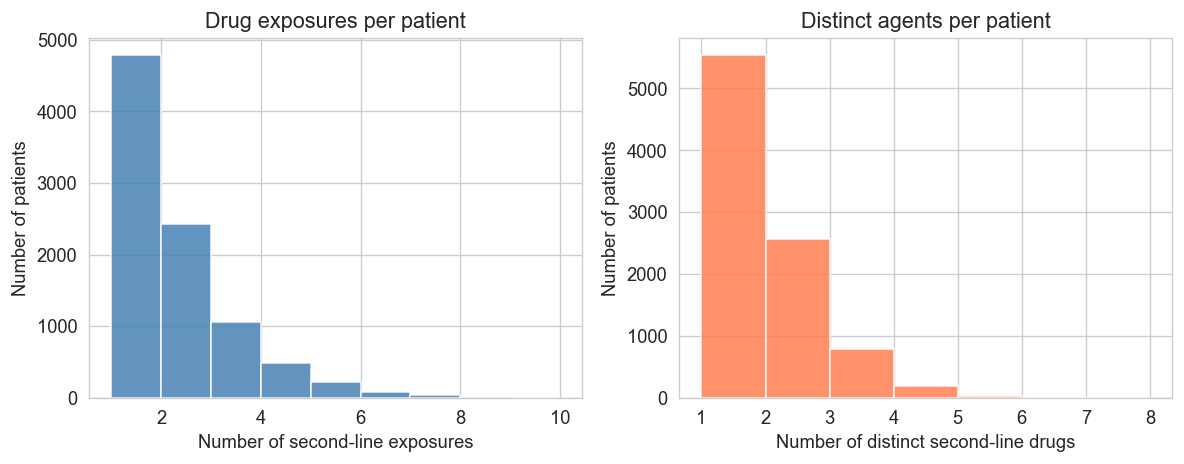

In [168]:
# Sort all exposures by patient and date
pathways = df_raw.sort_values(["person_id", "second_line_start_date"]).copy()

# Build ordered drug sequence per patient
patient_sequences = (
    pathways.groupby("person_id")["second_line_drug_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"second_line_drug_name": "drug_sequence"})
)

# Number of exposures per patient
patient_sequences["n_exposures"] = patient_sequences["drug_sequence"].apply(len)

# Number of distinct drugs per patient
patient_sequences["n_distinct_drugs"] = patient_sequences["drug_sequence"].apply(
    lambda x: len(set(x))
)

print("Exposures per patient:")
print(patient_sequences["n_exposures"].describe().round(1))
print()
print("Distinct second-line drugs per patient:")
print(patient_sequences["n_distinct_drugs"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
patient_sequences["n_exposures"].hist(
    ax=axes[0],
    bins=range(1, patient_sequences["n_exposures"].max() + 2),
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)
axes[0].set_xlabel("Number of second-line exposures")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Drug exposures per patient")

patient_sequences["n_distinct_drugs"].hist(
    ax=axes[1],
    bins=range(1, patient_sequences["n_distinct_drugs"].max() + 2),
    color="coral",
    edgecolor="white",
    alpha=0.85,
)
axes[1].set_xlabel("Number of distinct second-line drugs")
axes[1].set_ylabel("Number of patients")
axes[1].set_title("Distinct agents per patient")

plt.tight_layout()
plt.show()

### 4.2 Most Common Treatment Pathways

The top treatment pathways (ordered sequences of second-line drugs) observed in the cohort. Each pathway is read left to right as the temporal order of drugs received.

In [169]:
# Convert sequences to readable pathway strings. Dedupe first.
patient_sequences["drug_sequence"] = patient_sequences["drug_sequence"].apply(
    lambda seq: [seq[0]] + [seq[i] for i in range(1, len(seq)) if seq[i] != seq[i - 1]]
)
patient_sequences["pathway"] = patient_sequences["drug_sequence"].apply(
    lambda x: " → ".join(x)
)

# Top pathways
pathway_counts = patient_sequences["pathway"].value_counts().head(15)

print("Top 15 treatment pathways after metformin:")
print("=" * 65)
for i, (pathway, n) in enumerate(pathway_counts.items(), 1):
    pct = n / len(patient_sequences) * 100
    print(f"  {i:>2d}. [{n:>2d} pts, {pct:>4.1f}%]  metformin → {pathway}")

Top 15 treatment pathways after metformin:
   1. [2522 pts, 27.7%]  metformin → glyburide
   2. [1524 pts, 16.7%]  metformin → glipizide
   3. [490 pts,  5.4%]  metformin → rosiglitazone
   4. [396 pts,  4.3%]  metformin → glyburide → glipizide
   5. [378 pts,  4.1%]  metformin → glimepiride
   6. [364 pts,  4.0%]  metformin → glipizide → glyburide
   7. [364 pts,  4.0%]  metformin → pioglitazone
   8. [154 pts,  1.7%]  metformin → rosiglitazone → glyburide
   9. [142 pts,  1.6%]  metformin → sitagliptin
  10. [119 pts,  1.3%]  metformin → glyburide → rosiglitazone
  11. [110 pts,  1.2%]  metformin → glyburide → glimepiride
  12. [109 pts,  1.2%]  metformin → rosiglitazone → glipizide
  13. [83 pts,  0.9%]  metformin → pioglitazone → glyburide
  14. [83 pts,  0.9%]  metformin → glyburide → pioglitazone
  15. [82 pts,  0.9%]  metformin → glyburide → glipizide → glyburide


### 4.3 State Transition Analysis

Which drugs do patients transition *between*? This matrix shows the count of observed transitions from one second-line drug to the next in the treatment sequence.

State transition matrix (from → to):
to_drug           glimepiride  glipizide  glyburide  insulin detemir  \
from_drug                                                              
glimepiride                 0        205        200                0   
glipizide                 229          0        848                1   
glyburide                 282        876          0                2   
insulin detemir             0          1          1                0   
insulin glargine            2         10          7                0   
nateglinide                 5         19         31                0   
pioglitazone               57        156        219                0   
repaglinide                 9         28         45                0   
rosiglitazone              83        256        357                2   
saxagliptin                 1          1          0                0   
sitagliptin                25         53         83                0   
All                       6

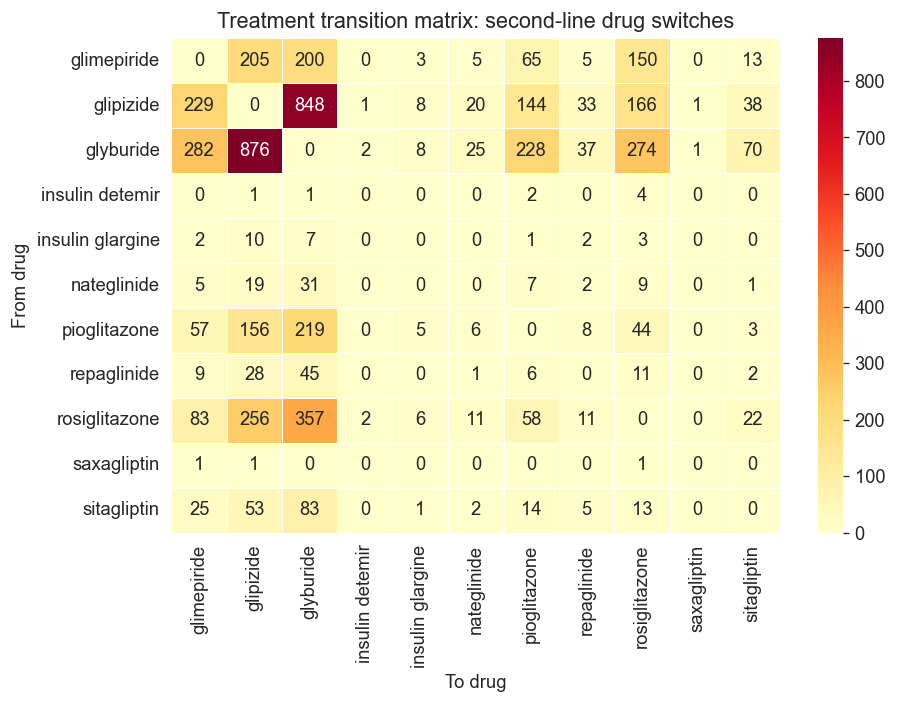


Top 10 most common transitions:
  glyburide → glipizide: 876
  glipizide → glyburide: 848
  rosiglitazone → glyburide: 357
  glyburide → glimepiride: 282
  glyburide → rosiglitazone: 274
  rosiglitazone → glipizide: 256
  glipizide → glimepiride: 229
  glyburide → pioglitazone: 228
  pioglitazone → glyburide: 219
  glimepiride → glipizide: 205


In [170]:
# Build transition pairs
transitions = []
for _, row in patient_sequences.iterrows():
    seq = row['drug_sequence']
    for i in range(len(seq) - 1):
        transitions.append((seq[i], seq[i+1]))

if len(transitions) > 0:
    trans_df = pd.DataFrame(transitions, columns=['from_drug', 'to_drug'])
    
    # Transition matrix
    trans_matrix = pd.crosstab(trans_df['from_drug'], trans_df['to_drug'], margins=True)
    print("State transition matrix (from → to):")
    print(trans_matrix)
    print()
    
    # Heatmap (without margins)
    trans_clean = pd.crosstab(trans_df['from_drug'], trans_df['to_drug'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(trans_clean, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('To drug')
    ax.set_ylabel('From drug')
    ax.set_title('Treatment transition matrix: second-line drug switches')
    plt.tight_layout()
    plt.show()
    
    # Most common transitions
    print("\nTop 10 most common transitions:")
    top_trans = trans_df.value_counts().head(10)
    for (fr, to), n in top_trans.items():
        print(f"  {fr} → {to}: {n}")
else:
    print("No transitions observed (all patients had only one second-line drug).")

### 4.4 Drug Class Grouping

Grouping individual drugs into pharmacologic classes to reveal higher-level treatment patterns.

First second-line agent by drug class:
----------------------------------------
  Sulfonylurea               n=4096  (79.4%)
  Thiazolidinedione          n=809  (15.7%)
  Meglitinide                n=143  (2.8%)
  DPP-4 inhibitor            n= 90  (1.7%)
  Other                      n= 23  (0.4%)


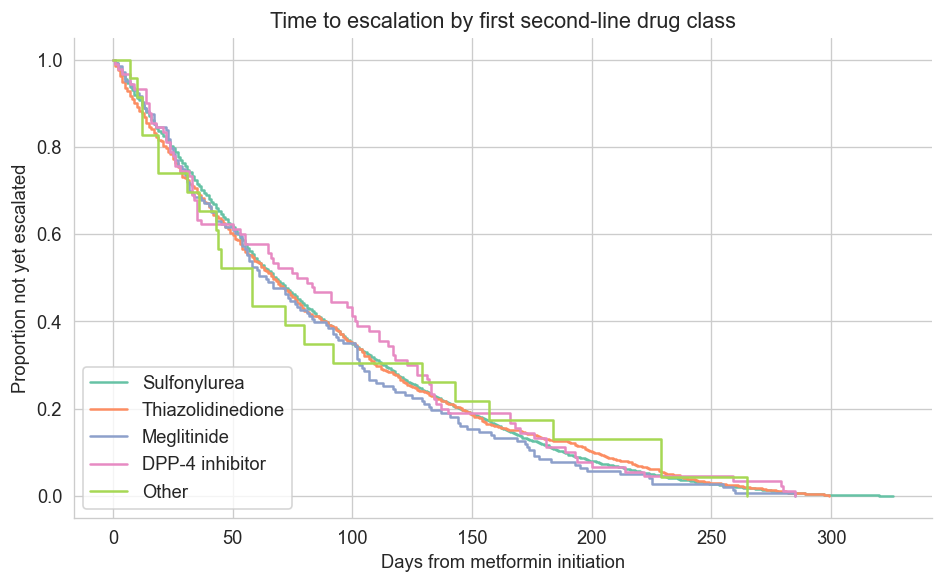

In [171]:
# Drug class mapping
drug_class_map = {
    'glyburide': 'Sulfonylurea',
    'glipizide': 'Sulfonylurea',
    'glimepiride': 'Sulfonylurea',
    'pioglitazone': 'Thiazolidinedione',
    'rosiglitazone': 'Thiazolidinedione',
    'sitagliptin': 'DPP-4 inhibitor',
    'nateglinide': 'Meglitinide',
    'repaglinide': 'Meglitinide',
}

# Map first drug to class
df['first_drug_class'] = df['second_line_drug_name'].map(drug_class_map).fillna('Other')

# Class distribution
class_counts = df['first_drug_class'].value_counts()
print("First second-line agent by drug class:")
print("-" * 40)
for cls, n in class_counts.items():
    print(f"  {cls:<25s}  n={n:>3d}  ({n/len(df)*100:.1f}%)")

# KM by drug class
fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()
palette = sns.color_palette("Set2", len(class_counts))

for i, cls in enumerate(class_counts.index):
    mask = df['first_drug_class'] == cls
    if mask.sum() >= 2:
        kmf.fit(df.loc[mask, 'time_to_escalation'],
                event_observed=df.loc[mask, 'event'],
                label=cls)
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])

ax.set_xlabel('Days from metformin initiation')
ax.set_ylabel('Proportion not yet escalated')
ax.set_title('Time to escalation by first second-line drug class')
ax.legend(loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Study Limitations and Methodological Notes

1. **Selection bias:** This dataset includes only patients who were escalated to a second-line agent. Patients who remained on metformin monotherapy throughout the observation period are excluded. All survival analyses therefore describe the *distribution of escalation timing among those who escalated*, not the overall probability of escalation.

2. **No censoring:** Because all patients in the dataset experienced the event, there are no censored observations. The KM estimator reduces to the empirical CDF, and the Cox model estimates relative differences in escalation speed without the usual censoring adjustments.

3. **Small sample size:** With ~50 unique patients, statistical power is limited. Confidence intervals on hazard ratios are wide, stratified analyses have very small cell sizes, and proportional hazards tests have low power. Results should be interpreted as exploratory.

4. **Unmeasured confounders:** Key clinical variables — HbA1c, BMI, renal function (eGFR), diabetes duration — are not available in this dataset. Prescriber behavior and clinical inertia are also unmeasured. As discussed in the DAG, disease severity is the most important unmeasured confounder.

5. **Observation intensity bias:** Patients with more healthcare encounters have more opportunities for escalation to be documented. Healthcare utilization is not available as a covariate in this extract.

6. **Temporal context:** The cohort start dates cluster around January 2009, which precedes the widespread adoption of SGLT2 inhibitors and GLP-1 receptor agonists. The treatment landscape reflected here is historically specific.

7. **Outcome definition:** The distinction between add-on therapy and drug switching is not explicitly modeled. Both are captured as "second-line initiation."